<a href="https://colab.research.google.com/github/AniruddhaGhosh64/india_runs/blob/main/INDIA_Runs_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A. Dataset Loading & Initial Exploration

In [ ]:
# A1. Import Required Libraries

import os
import gzip
import json
import pandas as pd
import numpy as np

from collections import Counter
from collections import defaultdict

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.metrics.pairwise import cosine_similarity

from tqdm import tqdm

In [ ]:
# A2. Skill Normalization Utilities

import re

def normalize_skill(skill):

    if pd.isna(skill):
        return ""

    skill = str(skill).lower().strip()

    # FIX: Changed regex from r"[\w\s\-+#]" to r"[^\w\s\-+#]"
    # The previous regex was incorrectly removing alphanumeric characters and common symbols,
    # rather than removing characters that are *not* alphanumeric/symbols.
    skill = re.sub(r"[^\w\s\-+#]", "", skill)

    synonyms = {

        # Languages
        "py": "python",
        "python3": "python",
        "js": "javascript",
        "ts": "typescript",

        # Cloud
        "gcp": "google cloud",
        "aws": "amazon web services",
        "azure cloud": "microsoft azure",

        # Containers
        "k8s": "kubernetes",
        "k8": "kubernetes",

        # Embeddings
        "sentence transformers": "embeddings",
        "sentence-transformers": "embeddings",
        "openai embeddings": "embeddings",
        "bge": "embeddings",
        "e5": "embeddings",

        # Retrieval
        "rag": "retrieval",
        "retrieval augmented generation": "retrieval",
        "dense retrieval": "retrieval",
        "hybrid retrieval": "retrieval",
        "semantic retrieval": "retrieval",
        "semantic search": "retrieval",

        # Vector Databases
        "pinecone": "vector database",
        "weaviate": "vector database",
        "qdrant": "vector database",
        "milvus": "vector database",
        "faiss": "vector database",

        # Search
        "elasticsearch": "search",
        "opensearch": "search",
        "bm25": "search",

        # Ranking
        "learning to rank": "ranking",
        "ltr": "ranking",
        "reranking": "ranking",
        "re-ranking": "ranking",
        "search ranking": "ranking",

        # Evaluation Metrics
        "normalized discounted cumulative gain": "ndcg",
        "mean reciprocal rank": "mrr",
        "mean average precision": "map",

        # Fine-tuning
        "low rank adaptation": "lora",
        "parameter efficient fine tuning": "peft",

        # LLMs
        "large language models": "llm",
        "llms": "llm",

        # Transformers
        "bert": "embeddings",
        "sentence bert": "embeddings",
        "sbert": "embeddings",

        # PostgreSQL
        "postgres": "postgresql",

    }

    return synonyms.get(skill, skill)

In [ ]:
# A3. Career Consistency Helper

def career_consistency(row):
    claimed = row.get("years_of_experience", 0)
    jobs = row.get("career_records", 0)
    if jobs == 0:
        return 0.60
    expected = jobs * 2
    diff = abs(claimed - expected)
    if diff <= 2: return 1.0
    elif diff <= 4: return 0.8
    elif diff <= 6: return 0.6
    elif diff <= 8: return 0.4
    else: return 0.2

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/candidates.jsonl"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n\n"
        "Check the exact location in Google Drive."
    )

print("✅ Dataset Found")

✅ Dataset Found


# B. Dataset Loading & Initial Exploration

**Purpose**

- Load the candidate dataset.
- Verify dataset structure and integrity.
- Create the primary analysis DataFrame.
- Perform an initial data quality audit.

In [ ]:
# B1. Load Candidate Dataset

LIMIT = None

def load_sample(fname, limit=None):
    data = []

    # Decide automatically
    if fname.endswith(".gz"):
        open_func = gzip.open
        mode = "rt"
    else:
        open_func = open
        mode = "r"

    with open_func(fname, mode, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if limit is not None and i >= limit:
                break

            try:
                data.append(json.loads(line))
            except Exception as e:
                print(f"Skipping line {i}: {e}")

    return data

print("Loading full candidate dataset...")

candidates = load_sample(DATA_PATH, LIMIT)

print(f"✅ Successfully loaded {len(candidates)} candidates")

Loading full candidate dataset...
✅ Successfully loaded 100000 candidates


In [ ]:
# B2. Dataset Summary

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Candidates Loaded: {len(candidates):,}")

print("\nTop Level Keys:")
print(sorted(candidates[0].keys()))

DATASET SUMMARY
Candidates Loaded: 100,000

Top Level Keys:
['candidate_id', 'career_history', 'certifications', 'education', 'languages', 'profile', 'redrob_signals', 'skills']


In [ ]:
# B3. Create Candidate DataFrame

candidate_df = pd.DataFrame(candidates)

print("Candidate Shape:", candidate_df.shape)

candidate_df.head()

Candidate Shape: (100000, 8)


,candidate_id,profile,career_history,education,skills,certifications,languages,redrob_signals
0,CAND_0000001,"{'anonymized_name': 'Ira Vora', 'headline': 'B...","[{'company': 'Mindtree', 'title': 'Backend Eng...",[{'institution': 'Lovely Professional Universi...,"[{'name': 'Tailwind', 'proficiency': 'intermed...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 86.9, 'signup_d..."
1,CAND_0000002,"{'anonymized_name': 'Saanvi Sethi', 'headline'...","[{'company': 'Wipro', 'title': 'Operations Man...","[{'institution': 'Local Engineering College', ...","[{'name': 'Project Management', 'proficiency':...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 78.7, 'signup_d..."
2,CAND_0000003,"{'anonymized_name': 'Yash Agarwal', 'headline'...","[{'company': 'TCS', 'title': 'Customer Support...","[{'institution': 'Local Engineering College', ...","[{'name': 'Angular', 'proficiency': 'intermedi...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 31.9, 'signup_d..."
3,CAND_0000004,"{'anonymized_name': 'Anil Bose', 'headline': '...","[{'company': 'Dunder Mifflin', 'title': 'Marke...","[{'institution': 'Local Engineering College', ...","[{'name': 'Node.js', 'proficiency': 'intermedi...","[{'name': 'AWS Certified Cloud Practitioner', ...","[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 28.5, 'signup_d..."
4,CAND_0000005,"{'anonymized_name': 'Aisha Sethi', 'headline':...","[{'company': 'Stark Industries', 'title': 'Acc...","[{'institution': 'Chandigarh University', 'deg...","[{'name': 'SQL', 'proficiency': 'beginner', 'e...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 84.6, 'signup_d..."


# C. Candidate Profile Preparation

**Purpose**

- Flatten nested candidate profile data.
- Clean and standardize ranking signals.
- Generate verification features for downstream scoring.

In [ ]:
# C2. Flatten Candidate Profile & Platform Signals

profile_df = pd.json_normalize(
    candidate_df["profile"]
)

signals_df = pd.json_normalize(
    candidate_df["redrob_signals"]
)

candidate_df = pd.concat(
    [
        candidate_df[["candidate_id"]],
        profile_df,
        signals_df
    ],
    axis=1
)

print(candidate_df.shape)

candidate_df.head()

(100000, 90)


,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,skill_assessment_scores.Python,skill_assessment_scores.OpenSearch,skill_assessment_scores.BM25,skill_assessment_scores.scikit-learn,skill_assessment_scores.pgvector,skill_assessment_scores.Embeddings,skill_assessment_scores.LlamaIndex,skill_assessment_scores.PyTorch,skill_assessment_scores.Deep Learning,skill_assessment_scores.QLoRA
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# C3. Clean Sentinel Values & Create Availability Flags

candidate_df["github_available"] = (
    candidate_df["github_activity_score"] != -1
)

candidate_df["offer_available"] = (
    candidate_df["offer_acceptance_rate"] != -1
)

candidate_df["github_activity_score"] = (
    candidate_df["github_activity_score"]
    .replace(-1, np.nan)
)

candidate_df["offer_acceptance_rate"] = (
    candidate_df["offer_acceptance_rate"]
    .replace(-1, np.nan)
)

In [ ]:
# C4. Compute Verification Features

candidate_df["verification_strength"] = (
    candidate_df["verified_email"].astype(int)
    + candidate_df["verified_phone"].astype(int)
    + candidate_df["linkedin_connected"].astype(int)
)

# Assign verification_strength to verification_score to make it available for display
candidate_df["verification_score"] = candidate_df["verification_strength"]

candidate_df[
    [
        "verification_strength",
        "verification_score"
    ]
].head()

,verification_strength,verification_score
0,2,2
1,0,0
2,1,1
3,3,3
4,2,2


# D. Skill Feature Engineering

**Purpose**

- Transform raw skill records into candidate-level skill features.
- Compute skill quality and trust metrics for ranking.

In [ ]:
# D1. Extract Candidate Skill Records

skill_rows = []

for cand in tqdm(candidates):
    cid = cand["candidate_id"]

    for skill in cand.get("skills", []):
        skill_rows.append({
            "candidate_id": cid,
            "skill":
                skill.get("name"), # Changed from skill.get("skill") to skill.get("name")
            "proficiency":
                skill.get("proficiency"),
            "endorsements":
                skill.get("endorsements"),
            "duration_months":
                skill.get("duration_months")
        })

skills_df = pd.DataFrame(skill_rows)
print("Skill Records:", len(skills_df))
skills_df.head()

100%|██████████| 100000/100000 [00:01<00:00, 72468.70it/s]


Skill Records: 960302


,candidate_id,skill,proficiency,endorsements,duration_months
0,CAND_0000001,Tailwind,intermediate,3,13
1,CAND_0000001,NLP,advanced,37,26
2,CAND_0000001,Image Classification,advanced,7,40
3,CAND_0000001,Fine-tuning LLMs,advanced,21,36
4,CAND_0000001,Weights & Biases,intermediate,13,30


In [ ]:
# D2. Candidate Skill Aggregates

candidate_skill_summary = (

    skills_df

    .groupby("candidate_id")

    .agg(
        total_skills = (
            "skill",
            "count"
        ),
        total_endorsements = (
            "endorsements",
            "sum"
        ),
        avg_endorsements = (
            "endorsements",
            "mean"
        ),
        avg_skill_duration = (
            "duration_months",
            "mean"
        )
    )
    .reset_index()
)

candidate_skill_summary.head()

,candidate_id,total_skills,total_endorsements,avg_endorsements,avg_skill_duration
0,CAND_0000001,17,292,17.176471,24.823529
1,CAND_0000002,9,70,7.777778,20.333333
2,CAND_0000003,6,47,7.833333,17.666667
3,CAND_0000004,10,80,8.000000,13.400000
4,CAND_0000005,6,88,14.666667,24.500000


In [ ]:
# D3. Skill Inventory Per Candidate

candidate_skill_map = (

    skills_df

    .groupby("candidate_id")["skill"]

    .apply(set)

    .to_dict()

)

print(
    "Candidates With Skills:",
    len(candidate_skill_map)
)

Candidates With Skills: 100000


In [ ]:
# D4. Compute Skill Trust Score

PROFICIENCY_MAP = {
    "beginner": 0.25,
    "intermediate": 0.55,
    "advanced": 0.80,
    "expert": 1.00
}

skills_df["proficiency_score"] = (
    skills_df["proficiency"]
    .fillna("")
    .str.lower()
    .map(PROFICIENCY_MAP)
    .fillna(0.50)
)

skills_df["endorsement_score"] = (
    skills_df["endorsements"]
    .fillna(0)
    .clip(upper=50)
    / 50
)

skills_df["duration_score"] = (
    skills_df["duration_months"]
    .fillna(0)
    .clip(upper=60)
    / 60
)

skills_df["skill_trust"] = (
      0.40 * skills_df["proficiency_score"]
    + 0.35 * skills_df["endorsement_score"]
    + 0.25 * skills_df["duration_score"]
)

skill_trust_df = (

    skills_df

    .groupby("candidate_id")["skill_trust"]

    .mean()

    .reset_index()

    .rename(
        columns={
            "skill_trust":"skill_trust_score"
        }
    )

)

skill_trust_df.head()

,candidate_id,skill_trust_score
0,CAND_0000001,0.460373
1,CAND_0000002,0.319167
2,CAND_0000003,0.288444
3,CAND_0000004,0.271833
4,CAND_0000005,0.381417


In [ ]:
# D5. Merge Skill Trust Features

candidate_df = candidate_df.merge(
    skill_trust_df,
    on="candidate_id",
    how="left"
)

candidate_df["skill_trust_score"] = (
    candidate_df["skill_trust_score"]
    .fillna(0)
)

candidate_df["skill_trust_score"] = (
    candidate_df["skill_trust_score"]
    - candidate_df["skill_trust_score"].min()
) / (
    candidate_df["skill_trust_score"].max()
    - candidate_df["skill_trust_score"].min()
)

candidate_df["skill_trust_score"].describe()

,skill_trust_score
count,100000.000000
mean,0.252535
std,0.086930
min,0.000000
25%,0.195595
50%,0.242630
75%,0.294379
max,1.000000


# E. Job Description Configuration

**Purpose**

- Define the target job requirements.
- Convert job criteria into structured matching rules.

In [ ]:
# E1. Configure Target Job Requirements

# ==========================================================
# JD Configuration (Redrob Senior AI Engineer)
# ==========================================================

JD_CONFIG = {

    "title": "Senior AI Engineer",

    "experience": {
        "min": 5,
        "preferred": (6, 8),
        "max": 9
    },

    "required_skills": {

        "python": 2.0,
        "embeddings": 2.0,
        "retrieval": 2.0,
        "ranking": 2.0,
        "vector database": 2.0,
        "information retrieval": 2.0,
        "search": 1.8,
        "evaluation": 1.8,
        "ndcg": 1.5,
        "mrr": 1.5,
        "map": 1.5

    },

    "preferred_skills": {

        "lora": 1.0,
        "qlora": 1.0,
        "peft": 1.0,
        "learning to rank": 1.0,
        "xgboost": 1.0,
        "hr tech": 0.8,
        "marketplace": 0.8,
        "distributed systems": 0.8,
        "inference optimization": 0.8,
        "open source": 0.8

    },

    "target_titles": [

        "Senior AI Engineer",
        "AI Engineer",
        "Machine Learning Engineer",
        "Applied ML Engineer",
        "LLM Engineer",
        "NLP Engineer",
        "Search Engineer",
        "Retrieval Engineer",
        "Recommendation Engineer"

    ],

    "adjacent_titles": [

        "ML Engineer",
        "Machine Learning Scientist",
        "Data Scientist",
        "ML Scientist",
        "Software Engineer AI",
        "Backend ML Engineer",
        "Applied Scientist",
        "Research Engineer",
        "AI Research Engineer",
        "Data Engineer",
        "MLE"

    ],

    "preferred_locations": [

        "Noida",
        "Pune",
        "Delhi NCR",
        "Hyderabad",
        "Mumbai"

    ],

    "disqualifier_flags": {

        "consulting_companies": {

            "tcs",
            "infosys",
            "wipro",
            "accenture",
            "cognizant",
            "capgemini"

        }
    }
}

In [ ]:
# E2. Build Job Skill Vocabulary

REQUIRED_SKILLS = {
    normalize_skill(k): v
    for k, v in JD_CONFIG["required_skills"].items()
}

PREFERRED_SKILLS = {
    normalize_skill(k): v
    for k, v in JD_CONFIG["preferred_skills"].items()
}

TARGET_TITLES = {
    t.lower()
    for t in JD_CONFIG["target_titles"]
}

ADJACENT_TITLES = {
    t.lower()
    for t in JD_CONFIG["adjacent_titles"]
}

In [ ]:
# E3. Parse Job Description Configuration

parsed_jd = {
    "required_skills": list(REQUIRED_SKILLS.keys()),
    "preferred_skills": list(PREFERRED_SKILLS.keys()),
    "target_titles": list(TARGET_TITLES),
    "adjacent_titles": list(ADJACENT_TITLES)
}

def extract_candidate_skills(skill_list):
    return {
        normalize_skill(skill)
        for skill in skill_list
        if pd.notna(skill)
    }

print(parsed_jd)

{'required_skills': ['python', 'embeddings', 'retrieval', 'ranking', 'vector database', 'information retrieval', 'search', 'evaluation', 'ndcg', 'mrr', 'map'], 'preferred_skills': ['lora', 'qlora', 'peft', 'ranking', 'xgboost', 'hr tech', 'marketplace', 'distributed systems', 'inference optimization', 'open source'], 'target_titles': ['senior ai engineer', 'ai engineer', 'retrieval engineer', 'nlp engineer', 'applied ml engineer', 'search engineer', 'recommendation engineer', 'machine learning engineer', 'llm engineer'], 'adjacent_titles': ['machine learning scientist', 'ml engineer', 'data scientist', 'ai research engineer', 'software engineer ai', 'backend ml engineer', 'ml scientist', 'applied scientist', 'data engineer', 'research engineer', 'mle']}


# F. Skill Matching Engine

**Purpose**

- Evaluate candidate skills against the target job requirements.
- Generate weighted skill matching features for ranking.

In [ ]:
# F1. Compute Skill Match Scores

def compute_skill_match(candidate_skills):

    required_matches = []
    preferred_matches = []

    required_skill_score = 0.0
    preferred_skill_score = 0.0

    for skill, weight in REQUIRED_SKILLS.items():
        if skill in candidate_skills:
            required_matches.append(skill)
            required_skill_score += weight

    for skill, weight in PREFERRED_SKILLS.items():
        if skill in candidate_skills:
            preferred_matches.append(skill)
            preferred_skill_score += weight

    max_required = max(sum(REQUIRED_SKILLS.values()), 1)
    max_preferred = max(sum(PREFERRED_SKILLS.values()), 1)

    return {

        "required_matches": required_matches,

        "preferred_matches": preferred_matches,

        "required_skill_score": required_skill_score / max_required,

        "preferred_skill_score": preferred_skill_score / max_preferred

    }

In [ ]:
# F2. Generate Candidate Skill Match Features

candidate_skill_scores = []

for candidate_id, candidate_skills in tqdm(candidate_skill_map.items()):

    candidate_skills = extract_candidate_skills(candidate_skills)

    result = compute_skill_match(candidate_skills)

    overall_skill_score = (
        0.8 * result["required_skill_score"] +
        0.2 * result["preferred_skill_score"]
    )

    candidate_skill_scores.append({
        "candidate_id": candidate_id,
        "required_skill_score": result["required_skill_score"],
        "preferred_skill_score": result["preferred_skill_score"],
        "skill_match_score": overall_skill_score,
        "matched_required_skills": len(result["required_matches"]),
        "matched_preferred_skills": len(result["preferred_matches"]),
        "required_matches": result["required_matches"],
        "preferred_matches": result["preferred_matches"]
    })

skill_match_df = pd.DataFrame(candidate_skill_scores)

assert (
    len(skill_match_df)
    == len(candidate_skill_map)
), "Mismatch in skill dataframe length."

assert (
    skill_match_df["candidate_id"]
    .is_unique
), "Duplicate candidate IDs found."

assert (
    skill_match_df["required_skill_score"]
    .between(0, 1)
    .all()
), "required_skill_score outside [0,1]."

assert (
    skill_match_df["preferred_skill_score"]
    .between(0, 1)
    .all()
), "preferred_skill_score outside [0,1]."

display(skill_match_df.head())

100%|██████████| 100000/100000 [00:10<00:00, 9348.48it/s]


,candidate_id,required_skill_score,preferred_skill_score,skill_match_score,matched_required_skills,matched_preferred_skills,required_matches,preferred_matches
0,CAND_0000001,0.099502,0.111111,0.101824,1,1,[vector database],[lora]
1,CAND_0000002,0.000000,0.000000,0.000000,0,0,[],[]
2,CAND_0000003,0.000000,0.000000,0.000000,0,0,[],[]
3,CAND_0000004,0.000000,0.000000,0.000000,0,0,[],[]
4,CAND_0000005,0.000000,0.000000,0.000000,0,0,[],[]


In [ ]:
# F3. Merge Skill Match Features

columns_to_drop = [
    "skill_match_score",
    "required_skill_score",
    "preferred_skill_score",
    "matched_required_skills",
    "matched_preferred_skills",
    "required_matches",
    "preferred_matches"
]

existing_cols = [
    c for c in columns_to_drop
    if c in candidate_df.columns
]

if existing_cols:
    candidate_df = candidate_df.drop(columns=existing_cols)

candidate_df = candidate_df.merge(

    skill_match_df[[
        "candidate_id",
        "skill_match_score",
        "required_skill_score",
        "preferred_skill_score",
        "matched_required_skills",
        "matched_preferred_skills",
        "required_matches",
        "preferred_matches"
    ]],
    on="candidate_id",
    how="left"
)

fill_zero = [
    "skill_match_score",
    "required_skill_score",
    "preferred_skill_score",
    "matched_required_skills",
    "matched_preferred_skills"
]

candidate_df[fill_zero] = candidate_df[fill_zero].fillna(0)

candidate_df["required_matches"] = [
    x if isinstance(x, list) else []
    for x in candidate_df["required_matches"]
]

candidate_df["preferred_matches"] = [
    x if isinstance(x, list) else []
    for x in candidate_df["preferred_matches"]
]
candidate_df.head()

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,verification_strength,verification_score,skill_trust_score,skill_match_score,required_skill_score,preferred_skill_score,matched_required_skills,matched_preferred_skills,required_matches,preferred_matches
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,2,2,0.475467,0.101824,0.099502,0.111111,1,1,[vector database],[lora]
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,0,0,0.259220,0.000000,0.000000,0.000000,0,0,[],[]
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,1,1,0.212171,0.000000,0.000000,0.000000,0,0,[],[]
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,3,3,0.186732,0.000000,0.000000,0.000000,0,0,[],[]
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,2,2,0.354551,0.000000,0.000000,0.000000,0,0,[],[]


# G. Behavioral Feature Engineering

**Purpose**

- Measure recruiter interest and platform engagement.
- Create behavioral ranking features.

In [ ]:
# G1. Normalize Behavioral Signals

behavior_cols = [
    "search_appearance_30d",
    "saved_by_recruiters_30d",
    "endorsements_received",
    "connection_count"
]

behavior_scaler = MinMaxScaler()

candidate_df[
    [f"{col}_scaled" for col in behavior_cols]
] = behavior_scaler.fit_transform(
    candidate_df[behavior_cols]
)

candidate_df.head()

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,required_skill_score,preferred_skill_score,matched_required_skills,matched_preferred_skills,required_matches,preferred_matches,search_appearance_30d_scaled,saved_by_recruiters_30d_scaled,endorsements_received_scaled,connection_count_scaled
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,0.099502,0.111111,1,1,[vector database],[lora],0.167114,0.0500,0.144628,0.183263
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,0.000000,0.000000,0,0,[],[],0.071812,0.1250,0.012397,0.089513
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,0.000000,0.000000,0,0,[],[],0.018792,0.0500,0.190083,0.004767
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,0.000000,0.000000,0,0,[],[],0.003356,0.1000,0.090909,0.251589
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,0.000000,0.000000,0,0,[],[],0.044966,0.0125,0.057851,0.153602


In [ ]:
# G2. Create Behavior Score

candidate_df["behavior_score"] = (
    0.40 *
    candidate_df["search_appearance_30d_scaled"] +
    0.30 *
    candidate_df["saved_by_recruiters_30d_scaled"] +
    0.20 *
    candidate_df["endorsements_received_scaled"] +
    0.10 *
    candidate_df["connection_count_scaled"]
)

candidate_df[
    [
        "candidate_id",
        "behavior_score"
    ]
].head()

,candidate_id,behavior_score
0,CAND_0000001,0.129098
1,CAND_0000002,0.077655
2,CAND_0000003,0.061010
3,CAND_0000004,0.074683
4,CAND_0000005,0.048667


# H. Experience & Career Analysis

**Purpose**

- Evaluate experience relevance and career progression.
- Generate career-based ranking features.

In [ ]:
# H1. Extract Career History Features
# Defined early to ensure linear flow and remove linter warnings

import pandas as pd

career_records = []

for cand in candidates:
    cid = cand['candidate_id']
    history = cand.get('career_history', [])

    if history:
        starts = []
        for job in history:
            sd = job.get('start_date')
            if sd:
                starts.append(pd.to_datetime(sd))

        if starts:
            earliest = min(starts)
            # Calculate longevity in years relative to a fixed reference date
            longevity = (pd.to_datetime('2026-05-20') - earliest).days / 365.25

            career_records.append({
                'candidate_id': cid,
                'earliest_job': earliest,
                'career_longevity_years': longevity
            })

career_df = pd.DataFrame(career_records)
print("career_df initialized successfully.")
display(career_df.head())

career_df initialized successfully.


,candidate_id,earliest_job,career_longevity_years
0,CAND_0000001,2019-07-03,6.880219
1,CAND_0000002,2014-01-23,12.320329
2,CAND_0000003,2025-05-02,1.048597
3,CAND_0000004,2022-08-02,3.797399
4,CAND_0000005,2015-09-08,10.696783


In [ ]:
# H2. Compute Experience Score

PREFERRED_MIN = JD_CONFIG["experience"]["preferred"][0]
PREFERRED_MAX = JD_CONFIG["experience"]["preferred"][1]

def experience_score(years):

    if pd.isna(years):
        return 0

    if years < PREFERRED_MIN:
        return max(years / PREFERRED_MIN, 0)

    if years <= PREFERRED_MAX:
        return 1.0

    excess = years - PREFERRED_MAX

    return max(1 - excess / 15, 0.5)

candidate_df["experience_score"] = (
    candidate_df["years_of_experience"]
    .apply(experience_score)
)

candidate_df[
    [
        "years_of_experience",
        "experience_score"
    ]
].head()

,years_of_experience,experience_score
0,6.9,1.000000
1,12.5,0.700000
2,1.1,0.183333
3,3.8,0.633333
4,11.0,0.800000


In [ ]:
# H3. Compute Title Match Score

def compute_title_score(title):

    if pd.isna(title):
        return 0.0

    title = str(title).lower().strip()

    # Exact JD target titles
    if title in TARGET_TITLES:
        return 1.00

    # Contains target titles
    title_tokens = set(title.split())

    for target in TARGET_TITLES:

        target_tokens = set(target.split())

        if target_tokens.issubset(title_tokens):
            return 0.95

    # Adjacent titles
    if any(t in title for t in ADJACENT_TITLES):
        return 0.85

    # Strong AI / ML keywords
    if any(k in title for k in [
        "machine learning",
        "ml engineer",
        "ai engineer",
        "artificial intelligence",
        "llm",
        "nlp",
        "retrieval",
        "search",
        "ranking",
        "recommendation"
    ]):
        return 0.75

    # Technical but not directly AI
    if any(k in title for k in [
        "backend",
        "software",
        "platform",
        "data engineer"
    ]):
        return 0.55

    # Generic engineering
    if "engineer" in title:
        return 0.50

    # Scientist roles
    if "research scientist" in title:
        return 0.60

    if "scientist" in title:
        return 0.50

    return 0.0


candidate_df["title_match_score"] = (
    candidate_df["current_title"]
    .fillna("")
    .apply(compute_title_score)
)

display(
    candidate_df[
        [
            "current_title",
            "title_match_score"
        ]
    ].head()
)

,current_title,title_match_score
0,Backend Engineer,0.55
1,Operations Manager,0.00
2,Customer Support,0.00
3,Marketing Manager,0.00
4,Accountant,0.00


In [ ]:
# H4. Compute Career Consistency Score

career_counts = (
    career_df
    .groupby("candidate_id")
    .size()
    .reset_index(name="career_records")
)

candidate_df = candidate_df.merge(
    career_counts,
    on="candidate_id",
    how="left"
)

candidate_df["career_records"] = (
    candidate_df["career_records"]
    .fillna(0)
)

def career_consistency(row):

    claimed = row["years_of_experience"]
    jobs = row["career_records"]

    # No history available
    if jobs == 0:
        return 0.60

    # Rough expectation:
    # ~2 years per job on average
    expected = jobs * 2

    diff = abs(claimed - expected)

    if diff <= 2:
        return 1.0
    elif diff <= 4:
        return 0.8
    elif diff <= 6:
        return 0.6
    elif diff <= 8:
        return 0.4
    else:
        return 0.2

candidate_df["career_consistency_score"] = (
    candidate_df.apply(
        career_consistency,
        axis=1
    )
)

candidate_df[
    [
        "career_records",
        "years_of_experience",
        "career_consistency_score"
    ]
].head()

,career_records,years_of_experience,career_consistency_score
0,1,6.9,0.6
1,1,12.5,0.2
2,1,1.1,1.0
3,1,3.8,1.0
4,1,11.0,0.2


In [ ]:
# H5. Compute Career Longevity Score
# Drop if exists for clean re-run - added errors='ignore' to prevent KeyError

columns_to_cleanup = ["career_longevity_years", "earliest_job", "longevity_score"]
existing_cols = [c for c in columns_to_cleanup if c in candidate_df.columns]
if existing_cols:
    candidate_df = candidate_df.drop(columns=existing_cols, errors='ignore')

candidate_df = candidate_df.merge(
    career_df[["candidate_id", "career_longevity_years"]],
    on="candidate_id",
    how="left"
)

# Fill NaNs with 0 (for those with no career history data)
candidate_df["career_longevity_years"] = candidate_df["career_longevity_years"].fillna(0)

# Normalize it to a 0-1 score
longevity_scaler = MinMaxScaler()
candidate_df["longevity_score"] = longevity_scaler.fit_transform(candidate_df[["career_longevity_years"]])

display(candidate_df[["candidate_id", "years_of_experience", "career_longevity_years", "longevity_score"]].head())

,candidate_id,years_of_experience,career_longevity_years,longevity_score
0,CAND_0000001,6.9,6.880219,0.418605
1,CAND_0000002,12.5,12.320329,0.803682
2,CAND_0000003,1.1,1.048597,0.005814
3,CAND_0000004,3.8,3.797399,0.200388
4,CAND_0000005,11.0,10.696783,0.688760


# I. Assessment Feature Engineering

**Purpose**

- Extract candidate assessment results.
- Generate assessment-based ranking features.

In [ ]:
# I1. Extract Assessment Records

assessment_rows = []

for candidate in tqdm(candidates):
    cid = candidate["candidate_id"]

    # Access skill_assessment_scores from redrob_signals
    assessments = candidate.get(
        "redrob_signals", {}
    ).get("skill_assessment_scores", {})

    for skill, score in assessments.items():
        assessment_rows.append({
            "candidate_id": cid,
            "skill": skill,
            "score": score
        })

assessment_df = pd.DataFrame(
    assessment_rows
)

print(
    "Assessment Records:",
    len(assessment_df)
)

display(
    assessment_df.head()
)

100%|██████████| 100000/100000 [00:00<00:00, 397332.36it/s]


Assessment Records: 35895


,candidate_id,skill,score
0,CAND_0000001,NLP,38.8
1,CAND_0000001,Image Classification,64.8
2,CAND_0000001,Fine-tuning LLMs,41.6
3,CAND_0000001,Speech Recognition,53.7
4,CAND_0000010,GANs,53.3


In [ ]:
# I2. Candidate Assessment Summary

assessment_summary = (
    assessment_df
    .groupby("candidate_id")
    .agg(
        assessment_score=(
            "score",
            "mean"
        )
    )
    .reset_index()
)

assessment_summary.head()

,candidate_id,assessment_score
0,CAND_0000001,49.725
1,CAND_0000010,68.475
2,CAND_0000011,29.800
3,CAND_0000014,77.600
4,CAND_0000020,53.700


In [ ]:
# I3. Merge Assessment Features

candidate_df = candidate_df.merge(
    assessment_summary,
    on="candidate_id",
    how="left"
)

candidate_df["assessment_available"] = (
    candidate_df["assessment_score"]
    .notna()
)

candidate_df["assessment_score"] = (
    candidate_df["assessment_score"]
    .fillna(0)
)

candidate_df.head()

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,connection_count_scaled,behavior_score,experience_score,title_match_score,career_records,career_consistency_score,career_longevity_years,longevity_score,assessment_score,assessment_available
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,0.183263,0.129098,1.000000,0.55,1,0.6,6.880219,0.418605,49.725,True
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,0.089513,0.077655,0.700000,0.00,1,0.2,12.320329,0.803682,0.000,False
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,0.004767,0.061010,0.183333,0.00,1,1.0,1.048597,0.005814,0.000,False
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,0.251589,0.074683,0.633333,0.00,1,1.0,3.797399,0.200388,0.000,False
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,0.153602,0.048667,0.800000,0.00,1,0.2,10.696783,0.688760,0.000,False


# J. Trust & Verification Engine

**Purpose**

- Quantify profile authenticity.
- Generate trust-based ranking features.

In [ ]:
# J1. Normalize Verification Features

trust_scaler = MinMaxScaler()

candidate_df["verification_score_scaled"] = (
    trust_scaler.fit_transform(
        candidate_df[
            ["verification_score"]
        ]
    )
)

candidate_df.head()

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,behavior_score,experience_score,title_match_score,career_records,career_consistency_score,career_longevity_years,longevity_score,assessment_score,assessment_available,verification_score_scaled
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,0.129098,1.000000,0.55,1,0.6,6.880219,0.418605,49.725,True,0.666667
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,0.077655,0.700000,0.00,1,0.2,12.320329,0.803682,0.000,False,0.000000
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,0.061010,0.183333,0.00,1,1.0,1.048597,0.005814,0.000,False,0.333333
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,0.074683,0.633333,0.00,1,1.0,3.797399,0.200388,0.000,False,1.000000
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,0.048667,0.800000,0.00,1,0.2,10.696783,0.688760,0.000,False,0.666667


In [ ]:
# J2. Compute Trust Score

candidate_df["trust_score"] = (
    0.60 *
    candidate_df["verification_score_scaled"] +
    0.40 *
    (
        candidate_df["verification_strength"] / 3
    )
)

candidate_df[
    [
        "candidate_id",
        "trust_score"
    ]

].head()

,candidate_id,trust_score
0,CAND_0000001,0.666667
1,CAND_0000002,0.000000
2,CAND_0000003,0.333333
3,CAND_0000004,1.000000
4,CAND_0000005,0.666667


# K. Candidate Activity Engine

**Purpose**

- Measure candidate activity and profile freshness.
- Generate activity-based ranking features.

In [ ]:
# K1. Normalize Activity Features

activity_cols = [
    "profile_completeness_score",
    "interview_completion_rate"
]

scaler = MinMaxScaler()

candidate_df[
    [f"{col}_scaled" for col in activity_cols]
] = scaler.fit_transform(
    candidate_df[activity_cols]
)

In [ ]:
# K2. Compute Activity Recency Score
# Ensure 'signup_date' and 'last_active_date' are datetime objects

candidate_df["signup_date"] = pd.to_datetime(
    candidate_df["signup_date"]
)
candidate_df["last_active_date"] = pd.to_datetime(
    candidate_df["last_active_date"]
)

# Calculate REFERENCE_DATE based on candidate_df
REFERENCE_DATE = candidate_df["last_active_date"].max()

candidate_df["days_since_active"] = (
    REFERENCE_DATE -
    candidate_df["last_active_date"]
).dt.days

candidate_df["recency_score"] = (
    1 -
    (
        candidate_df["days_since_active"]
        /
        candidate_df["days_since_active"].max()
    )
)

candidate_df["recency_score"] = (
    candidate_df["recency_score"]
    .clip(0, 1)
)

candidate_df.head()

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,career_longevity_years,longevity_score,assessment_score,assessment_available,verification_score_scaled,trust_score,profile_completeness_score_scaled,interview_completion_rate_scaled,days_since_active,recency_score
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,6.880219,0.418605,49.725,True,0.666667,0.666667,0.826435,0.585714,7,0.970833
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,12.320329,0.803682,0.000,False,0.000000,0.000000,0.716956,0.457143,196,0.183333
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,1.048597,0.005814,0.000,False,0.333333,0.333333,0.092123,0.800000,67,0.720833
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,3.797399,0.200388,0.000,False,1.000000,1.000000,0.046729,0.071429,63,0.737500
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,10.696783,0.688760,0.000,False,0.666667,0.666667,0.795728,0.628571,238,0.008333


In [ ]:
# K3. Compute Activity Score

candidate_df["activity_score"] = (
    0.40 * candidate_df["recency_score"]
    + 0.35 * candidate_df["profile_completeness_score_scaled"]
    + 0.25 * candidate_df["interview_completion_rate_scaled"]
)

candidate_df[
    [
        "candidate_id",
        "activity_score"
    ]
].head()

,candidate_id,activity_score
0,CAND_0000001,0.824014
1,CAND_0000002,0.438554
2,CAND_0000003,0.520576
3,CAND_0000004,0.329212
4,CAND_0000005,0.438981


# L. Profile Integrity Engine

**Purpose**

- Evaluate profile consistency and credibility.
- Generate integrity-based ranking features.

In [ ]:
# L1. Compute Profile Integrity Signals

candidate_df["timeline_integrity"] = 1.0

candidate_df.loc[
    candidate_df["years_of_experience"] < 0,
    "timeline_integrity"
] = 0.0

candidate_df.loc[
    candidate_df["years_of_experience"] > 35,
    "timeline_integrity"
] = 0.5

candidate_df.loc[
    candidate_df["years_of_experience"] > 45,
    "timeline_integrity"
] = 0.0


# Career Integrity
candidate_df["career_integrity"] = (
    1
    -
    (
        candidate_df["career_consistency_score"]
        .clip(0, 1)
        .rsub(1)
    )
)

candidate_df["career_integrity"] = (
    candidate_df["career_integrity"]
    .clip(0, 1)
)


# Skill Integrity
candidate_df["skill_integrity"] = (
    (
        candidate_df["skill_trust_score"]
        +
        candidate_df["trust_score"]
    )
    / 2
).clip(0, 1)


# Verification Integrity

candidate_df["verification_integrity"] = (
    candidate_df["verification_strength"] / 3
).clip(0, 1)

In [ ]:
# L2. Compute Profile Integrity Score

candidate_df["structural_integrity_score"] = (

      0.30 * candidate_df["timeline_integrity"]
    + 0.30 * candidate_df["career_integrity"]
    + 0.20 * candidate_df["skill_integrity"]
    + 0.20 * candidate_df["verification_integrity"]

)

candidate_df["structural_integrity_score"] = (
    candidate_df["structural_integrity_score"]
    .clip(0, 1)
)

assert (
    candidate_df["structural_integrity_score"]
    .between(0,1)
    .all()
), "Structural integrity score outside [0,1]."

In [ ]:
# L3. Flag Low-Integrity Profiles

candidate_df["low_integrity_flag"] = (
    candidate_df["structural_integrity_score"] < 0.60
)

print("Structural Integrity Distribution")

display(
    candidate_df[
        "structural_integrity_score"
    ].describe()
)

print("\nLow Integrity Profiles")

display(
    candidate_df[
        "low_integrity_flag"
    ].value_counts()
)

Structural Integrity Distribution


,structural_integrity_score
count,100000.000000
mean,0.678346
std,0.128139
min,0.360291
25%,0.583765
50%,0.683113
75%,0.768935
max,0.981240



Low Integrity Profiles


,count
low_integrity_flag,
False,69282
True,30718


# M. JD Compatibility & Disqualification Engine

**Purpose**

- Identify candidates with potential job-fit concerns.
- Generate compatibility flags for ranking adjustments.

In [ ]:
# M1. Compute JD Disqualifier Flags

CONSULTING_COMPANIES = set(
    company.lower()
    for company in JD_CONFIG["disqualifier_flags"]["consulting_companies"]
)

RESEARCH_KEYWORDS = [
    "research",
    "research scientist",
    "research engineer",
    "research associate",
    "phd",
    "doctoral",
    "laboratory",
    "lab"
]

CV_KEYWORDS = [
    "computer vision",
    "object detection",
    "image classification",
    "image segmentation",
    "opencv",
    "yolo"
]

SPEECH_KEYWORDS = [
    "speech",
    "speech recognition",
    "asr",
    "tts"
]

ROBOTICS_KEYWORDS = [
    "robotics",
    "slam",
    "autonomous",
    "path planning"
]


def contains_any(text, keywords):
    if not text:
        return False

    text = str(text).lower()

    return any(
        keyword in text
        for keyword in keywords
    )

jd_flag_rows = []

for cand in tqdm(candidates):
    candidate_id = cand["candidate_id"]
    history = cand.get("career_history", [])

    if not history:
        jd_flag_rows.append({
            "candidate_id": candidate_id,
            "consulting_only": False,
            "research_heavy": False,
            "domain_mismatch": False
        })
        continue

    companies = []

    research_roles = 0
    domain_roles = 0

    for job in history:

        company = str(
            job.get("company", "")
        ).lower()

        title = str(
            job.get("title", "")
        ).lower()

        description = str(
            job.get("description", "")
        ).lower()

        combined = title + " " + description

        if company:
            companies.append(company)

        if contains_any(
            combined,
            RESEARCH_KEYWORDS
        ):
            research_roles += 1

        if (
            contains_any(combined, CV_KEYWORDS)
            or
            contains_any(combined, SPEECH_KEYWORDS)
            or
            contains_any(combined, ROBOTICS_KEYWORDS)
        ):
            domain_roles += 1

    consulting_only = (
        len(companies) > 0
        and
        all(
            any(
                consulting in company
                for consulting in CONSULTING_COMPANIES
            )
            for company in companies
        )
    )

    research_heavy = (
        research_roles >=
        max(
            1,
            len(history) * 0.6
        )
    )
    domain_mismatch = (
        domain_roles >=
        max(
            1,
            len(history) * 0.6
        )
    )

    jd_flag_rows.append({

        "candidate_id": candidate_id,
        "consulting_only": consulting_only,
        "research_heavy": research_heavy,
        "domain_mismatch": domain_mismatch
    })

jd_flag_df = pd.DataFrame(jd_flag_rows)

# Drop existing 'consulting_only' column from candidate_df if it exists,
# as it would have been added by a previous cell and conflicts with the new merge.
if 'consulting_only' in candidate_df.columns:
    candidate_df = candidate_df.drop(columns=['consulting_only'])

candidate_df = candidate_df.merge(
    jd_flag_df,
    on="candidate_id",
    how="left"
)

flag_cols = [
    "consulting_only",
    "research_heavy",
    "domain_mismatch"
]

candidate_df[flag_cols] = (
    candidate_df[flag_cols]
    .fillna(False)
)

display(
    candidate_df[
        [
            "candidate_id",
            "consulting_only",
            "research_heavy",
            "domain_mismatch"
        ]
    ].head()
)

100%|██████████| 100000/100000 [00:08<00:00, 11689.14it/s]


,candidate_id,consulting_only,research_heavy,domain_mismatch
0,CAND_0000001,False,False,False
1,CAND_0000002,False,False,False
2,CAND_0000003,True,False,False
3,CAND_0000004,False,False,False
4,CAND_0000005,False,False,False


In [ ]:
# M2. Detect Framework-Only Profiles

FRAMEWORK_SKILLS = {
    "langchain",
    "crewai",
    "autogen",
    "openai api",
    "llamaindex"
}

FOUNDATION_SKILLS = {

    "retrieval",
    "ranking",
    "information retrieval",
    "embeddings",
    "vector database",
    "pinecone",
    "qdrant",
    "weaviate",
    "faiss",
    "milvus",
    "elasticsearch",
    "opensearch",
    "ndcg",
    "mrr",
    "map",
    "learning to rank"
}

def compute_framework_only(row):

    skills = {
        str(skill).lower()
        for skill in (
            row["required_matches"] +
            row["preferred_matches"]
        )
    }

    has_framework = any(
        skill in FRAMEWORK_SKILLS
        for skill in skills
    )

    has_foundation = any(
        skill in FOUNDATION_SKILLS
        for skill in skills
    )

    return (
        has_framework
        and
        not has_foundation
    )

candidate_df["framework_only"] = (
    candidate_df.apply(
        compute_framework_only,
        axis=1
    )
)

In [ ]:
# M3. Compute Additional JD Compatibility Flags

ENGINEERING_KEYWORDS = {
    "engineer", "developer", "machine learning", "ml",
    "ai", "software", "backend", "search",
    "retrieval", "ranking", "data"
}

LEADERSHIP_KEYWORDS = {
    "architect", "manager", "director",
    "vp", "head", "principal"
}

production_gap_rows = []

for cand in tqdm(candidates):

    production_gap = True

    for job in cand.get("career_history", []):

        title = str(job.get("title", "")).lower()
        is_current = job.get("is_current", False)

        engineering_role = any(k in title for k in ENGINEERING_KEYWORDS)
        leadership_role = any(k in title for k in LEADERSHIP_KEYWORDS)

        if is_current and engineering_role:
            production_gap = False
            break

        if is_current and leadership_role:
            production_gap = True

    production_gap_rows.append({
        "candidate_id": cand["candidate_id"],
        "production_gap": production_gap
    })

production_gap_df = pd.DataFrame(production_gap_rows)

candidate_df = candidate_df.merge(
    production_gap_df,
    on="candidate_id",
    how="left"
)

candidate_df["production_gap"] = candidate_df["production_gap"].fillna(False)

candidate_df["title_mismatch"] = (
    (candidate_df["title_match_score"] < 0.40) &
    (candidate_df["skill_match_score"] >= 0.70)
)

JD_FLAG_COLUMNS = [
    "consulting_only",
    "research_heavy",
    "domain_mismatch",
    "framework_only",
    "production_gap",
    "title_mismatch"
]

candidate_df["jd_disqualifier_count"] = (
    candidate_df[JD_FLAG_COLUMNS]
    .fillna(False)
    .astype(int)
    .sum(axis=1)
)

display(
    candidate_df[
        JD_FLAG_COLUMNS + ["jd_disqualifier_count"]
    ].describe()
)

100%|██████████| 100000/100000 [00:01<00:00, 76436.03it/s]


,jd_disqualifier_count
count,100000.000000
mean,0.687320
std,0.580598
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,3.000000


# N. Product Experience Feature Engineering

**Purpose**

- Capture product-focused engineering experience.
- Generate product experience features for ranking.

In [ ]:
# N1. Extract Product Experience Features

PRODUCT_KEYWORDS = {
    "product",
    "platform",
    "search",
    "retrieval",
    "ranking",
    "recommendation",
    "recommendation system",
    "matching",
    "marketplace",
    "personalization"
}

ML_KEYWORDS = {
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "ai",
    "ml",
    "llm",
    "nlp"
}

SERVICE_INDUSTRIES = {
    "it services",
    "consulting",
    "outsourcing"
}

STARTUP_SIZES = {
    "1-10",
    "11-50",
    "51-200"
}

product_rows = []

for cand in tqdm(candidates):

    product_company = 0
    startup = 0
    retrieval = 0
    production_ml = 0

    history = cand.get("career_history", [])

    for job in history:

        description = str(job.get("description", "")).lower()
        industry = str(job.get("industry", "")).lower()
        company_size = str(job.get("company_size", ""))

        if industry and industry not in SERVICE_INDUSTRIES:
            product_company += 1

        if company_size in STARTUP_SIZES:
            startup += 1

        if any(k in description for k in PRODUCT_KEYWORDS):
            retrieval += 1

        if any(k in description for k in ML_KEYWORDS):
            production_ml += 1

    product_rows.append({
        "candidate_id": cand["candidate_id"],
        "product_company_score": product_company,
        "startup_score": startup,
        "retrieval_system_score": retrieval,
        "production_ml_score": production_ml
    })

product_df = pd.DataFrame(product_rows)

100%|██████████| 100000/100000 [00:04<00:00, 22546.19it/s]


In [ ]:
# N2. Merge Product Experience Features

candidate_df = candidate_df.merge(
    product_df,
    on="candidate_id",
    how="left"
)

PRODUCT_COLUMNS = [
    "product_company_score",
    "startup_score",
    "retrieval_system_score",
    "production_ml_score"
]

candidate_df[PRODUCT_COLUMNS] = (
    candidate_df[PRODUCT_COLUMNS]
    .fillna(0)
)

assert (
    candidate_df[PRODUCT_COLUMNS]
    .isna()
    .sum()
    .sum()
    == 0
), "NaN values remain in product feature columns."

In [ ]:
# N3. Compute Product Experience Score

scaler = MinMaxScaler()

candidate_df[PRODUCT_COLUMNS] = scaler.fit_transform(
    candidate_df[PRODUCT_COLUMNS]
)

candidate_df["product_experience_score"] = (
    0.35 * candidate_df["product_company_score"] +
    0.20 * candidate_df["startup_score"] +
    0.25 * candidate_df["retrieval_system_score"] +
    0.20 * candidate_df["production_ml_score"]
)

display(
    candidate_df[
        PRODUCT_COLUMNS + ["product_experience_score"]
    ].describe()
)

,product_company_score,startup_score,retrieval_system_score,production_ml_score,product_experience_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.261529,0.079553,0.218796,0.228661,0.207877
std,0.172414,0.116837,0.176762,0.170992,0.132247
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125000,0.000000,0.142857,0.125000,0.104464
50%,0.250000,0.000000,0.142857,0.250000,0.183929
75%,0.375000,0.166667,0.285714,0.375000,0.294643
max,1.000000,1.000000,1.000000,1.000000,0.861905


# O. Candidate Availability Engine

**Purpose**

- Estimate candidate availability for hiring.
- Generate availability features for ranking.

In [ ]:
# O1. Compute Availability Features

candidate_df["activity_recency_score"] = (
    1 - (candidate_df["days_since_active"] / 365)
).clip(0, 1)

candidate_df["response_score"] = (
    candidate_df["recruiter_response_rate"]
    .fillna(0)
    .clip(0, 1)
)

candidate_df["interview_score"] = (
    candidate_df["interview_completion_rate"]
    .fillna(0)
    .clip(0, 1)
)

candidate_df["offer_score"] = (
    candidate_df["offer_acceptance_rate"]
    .replace(-1, np.nan)
    .fillna(0.5)
    .clip(0, 1)
)

candidate_df["notice_period_score"] = (
    1 - (candidate_df["notice_period_days"] / 180)
).clip(0, 1)

candidate_df["open_to_work_score"] = (
    candidate_df["open_to_work_flag"]
    .astype(int)
)

In [ ]:
# O2. Compute Availability Score

candidate_df["availability_score"] = (
      0.25 * candidate_df["activity_recency_score"]
    + 0.20 * candidate_df["response_score"]
    + 0.20 * candidate_df["interview_score"]
    + 0.10 * candidate_df["offer_score"]
    + 0.10 * candidate_df["notice_period_score"]
    + 0.15 * candidate_df["open_to_work_score"]
)

candidate_df["availability_score"] = (
    candidate_df["availability_score"]
    .clip(0, 1)
)

display(
    candidate_df[
        [
            "availability_score",
            "activity_recency_score",
            "response_score",
            "interview_score",
            "offer_score",
            "notice_period_score",
            "open_to_work_score"
        ]
    ].describe()
)

,availability_score,activity_recency_score,response_score,interview_score,offer_score,notice_period_score,open_to_work_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.540180,0.702126,0.436574,0.619510,0.489706,0.514523,0.353390
std,0.108568,0.182434,0.214122,0.170662,0.113539,0.203276,0.478025
min,0.225968,0.342466,0.020000,0.300000,0.150000,0.166667,0.000000
25%,0.460579,0.556164,0.250000,0.480000,0.500000,0.333333,0.000000
50%,0.533514,0.712329,0.440000,0.620000,0.500000,0.500000,0.000000
75%,0.615759,0.857534,0.620000,0.760000,0.500000,0.666667,1.000000
max,0.916909,1.000000,0.950000,1.000000,0.930000,1.000000,1.000000


# P. Composite Ranking Engine

**Purpose**

- Combine all ranking signals into a final candidate score.
- Prepare features for downstream ranking analysis.

In [ ]:
# P1. Build Candidate Quality Summary

min_score = candidate_df["assessment_score"].min()
max_score = candidate_df["assessment_score"].max()

range_score = max_score - min_score

if range_score <= 1e-9:
      # If all scores are the same, normalized score is 0.0 (or a constant value like 0.5)
    candidate_df["assessment_score_norm"] = 0.0
else:
    candidate_df["assessment_score_norm"] = (
        (candidate_df["assessment_score"] - min_score) / (range_score)
    ).fillna(0) # Fill NaN with 0 for candidates without assessment scores

candidate_df["candidate_quality"] = [
    {
        "skills": s,
        "title": t,
        "experience": e,
        "behavior": b,
        "availability": a,
        "product": p,
        "integrity": i,
        "assessment": ass
    }
    for s, t, e, b, a, p, i, ass in zip(
        candidate_df["skill_match_score"],
        candidate_df["title_match_score"],
        candidate_df["experience_score"],
        candidate_df["behavior_score"],
        candidate_df["availability_score"],
        candidate_df["product_experience_score"],
        candidate_df["structural_integrity_score"],
        candidate_df["assessment_score_norm"]
    )
]

In [ ]:
# P2. Compute Final Composite Score

candidate_df["final_score"] = (
      0.25 * candidate_df["skill_match_score"]              # Technical skill fit
    + 0.15 * candidate_df["title_match_score"]              # Job title relevance
    + 0.18 * candidate_df["experience_score"]               # Experience fit
    + 0.12 * candidate_df["availability_score"]             # Recruiter availability
    + 0.08 * candidate_df["behavior_score"]                 # Platform engagement
    + 0.12 * candidate_df["product_experience_score"]       # Product engineering experience
    + 0.05 * candidate_df["structural_integrity_score"]     # Profile consistency
    + 0.05 * candidate_df["assessment_score_norm"]          # Assessment performance
)

# Soft JD Disqualifier Penalty
# Maximum penalty capped at 15%

penalty = (
    candidate_df["jd_disqualifier_count"]
    .clip(0, 3)
)

candidate_df["final_score"] *= (
    1 - penalty * 0.05
)

# Keep scores within valid range
candidate_df["final_score"] = (
    candidate_df["final_score"]
    .clip(0, 1)
)

assert (
    candidate_df["final_score"]
    .between(0, 1)
    .all()
), "Final score outside valid range."

display(
    candidate_df[
        [
            "candidate_id",
            "final_score"
        ]
    ].head()
)

,candidate_id,final_score
0,CAND_0000001,0.464259
1,CAND_0000002,0.240238
2,CAND_0000003,0.127003
3,CAND_0000004,0.232491
4,CAND_0000005,0.262704


In [ ]:
# P3. Summarize Ranking Features

ranking_features = [

    "skill_match_score",
    "required_skill_score",
    "preferred_skill_score",

    "title_match_score",

    "experience_score",
    "career_consistency_score",
    "longevity_score",

    "behavior_score",
    "availability_score",

    "product_experience_score",

    "structural_integrity_score",

    "assessment_score_norm",

    "trust_score",

    "jd_disqualifier_count",

    "final_score"

]

display(
    candidate_df[
        ranking_features
    ].describe()
)

,skill_match_score,required_skill_score,preferred_skill_score,title_match_score,experience_score,career_consistency_score,longevity_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,assessment_score_norm,trust_score,jd_disqualifier_count,final_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.030920,0.037113,0.006147,0.163494,0.740225,0.611006,0.428281,0.102904,0.540180,0.207877,0.678346,0.132085,0.565970,0.687320,0.294721
std,0.073133,0.089990,0.027729,0.251837,0.232825,0.305436,0.267151,0.050132,0.108568,0.132247,0.128139,0.245609,0.274829,0.580598,0.075488
min,0.000000,0.000000,0.000000,0.000000,0.166667,0.200000,0.000000,0.002833,0.225968,0.000000,0.360291,0.000000,0.000000,0.000000,0.099985
25%,0.000000,0.000000,0.000000,0.000000,0.583333,0.400000,0.203488,0.071746,0.460579,0.104464,0.583765,0.000000,0.333333,0.000000,0.247338
50%,0.000000,0.000000,0.000000,0.000000,0.783333,0.600000,0.403876,0.093379,0.533514,0.183929,0.683113,0.000000,0.666667,1.000000,0.285360
75%,0.000000,0.000000,0.000000,0.500000,0.953333,1.000000,0.622093,0.120491,0.615759,0.294643,0.768935,0.000000,0.666667,1.000000,0.339708
max,0.593698,0.686567,0.444444,1.000000,1.000000,1.000000,1.000000,0.825335,0.916909,0.861905,0.981240,1.000000,1.000000,3.000000,0.729795


# Q. Ranking Validation & Diagnostics

**Purpose**

- Validate the final ranking quality.
- Inspect top candidates and score distributions.

In [ ]:
# Q1. Generate Ranked Candidate Table

inspection_columns = [
    "candidate_id",
    "current_title",
    "years_of_experience",
    "final_score",
    "required_skill_score",
    "preferred_skill_score",
    "title_match_score",
    "experience_score",
    "behavior_score",
    "availability_score",
    "assessment_score",
    "product_experience_score",
    "structural_integrity_score",
    "candidate_quality",
    "jd_disqualifier_count"
]

inspection_columns = [
    c for c in inspection_columns
    if c in candidate_df.columns
]

ranked_df = (
    candidate_df[inspection_columns]
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)

ranked_df["rank"] = ranked_df.index + 1

assert (
    ranked_df["candidate_id"]
    .is_unique
), "Duplicate candidate IDs found in ranked dataframe."

assert (
    ranked_df["final_score"]
    .is_monotonic_decreasing
), "Ranking is not sorted by final_score."

print(f"Total candidates ranked : {len(ranked_df)}")
print(f"Highest score           : {ranked_df.final_score.max():.4f}")
print(f"Lowest score            : {ranked_df.final_score.min():.4f}")

Total candidates ranked : 100000
Highest score           : 0.7298
Lowest score            : 0.1000


R. Ranking Evaluation

In [ ]:
# R1. Ranking Overview

ranking_summary = pd.DataFrame({

    "Metric": [
        "Total Candidates",
        "Top 100 Candidates",
        "Highest Score",
        "Lowest Top100 Score",
        "Overall Mean Score",
        "Top100 Mean Score",
        "Median Score",
        "Score Std",
        "Duplicate Candidate IDs",
        "Duplicate Ranks",
        "Missing Scores"
    ],

    "Value": [
        len(candidate_df),
        len(ranked_df.head(100)),
        ranked_df["final_score"].max(),
        ranked_df.head(100)["final_score"].min(),
        ranked_df["final_score"].mean(),
        ranked_df.head(100)["final_score"].mean(),
        ranked_df["final_score"].median(),
        ranked_df["final_score"].std(),
        ranked_df["candidate_id"].duplicated().sum(),
        ranked_df["rank"].duplicated().sum(),
        ranked_df["final_score"].isna().sum()
    ]
})

display(ranking_summary)

assert ranked_df["candidate_id"].is_unique
assert ranked_df["rank"].is_unique
assert ranked_df["final_score"].between(0,1).all()
assert ranked_df["final_score"].is_monotonic_decreasing

,Metric,Value
0,Total Candidates,100000.000000
1,Top 100 Candidates,100.000000
2,Highest Score,0.729795
3,Lowest Top100 Score,0.602114
4,Overall Mean Score,0.294721
5,Top100 Mean Score,0.635616
6,Median Score,0.285360
7,Score Std,0.075488
8,Duplicate Candidate IDs,0.000000
9,Duplicate Ranks,0.000000


In [ ]:
# R2. Top Candidate Overview

overview_columns = [

    "rank",
    "candidate_id",
    "current_title",
    "years_of_experience",

    "required_skill_score",
    "preferred_skill_score",

    "title_match_score",
    "experience_score",

    "product_experience_score",
    "availability_score",

    "structural_integrity_score",

    "jd_disqualifier_count",

    "final_score"

]

overview_columns = [
    c for c in overview_columns
    if c in ranked_df.columns
]

display(
    ranked_df[overview_columns]
    .head(20)
    .style.background_gradient(
        subset=["final_score"],
        cmap="Greens"
    )
)

,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,product_experience_score,availability_score,structural_integrity_score,jd_disqualifier_count,final_score
0,1,CAND_0018499,Senior Machine Learning Engineer,7.200000,0.587065,0.222222,0.950000,1.000000,0.313393,0.839078,0.867993,0,0.729795
1,2,CAND_0008425,Senior NLP Engineer,7.800000,0.597015,0.222222,0.950000,1.000000,0.313393,0.755082,0.874212,0,0.719658
2,3,CAND_0081846,Lead AI Engineer,6.700000,0.686567,0.111111,0.950000,1.000000,0.208929,0.850895,0.871161,0,0.709867
3,4,CAND_0088025,Staff Machine Learning Engineer,8.600000,0.487562,0.333333,0.950000,0.960000,0.321726,0.879096,0.807496,0,0.705739
4,5,CAND_0077337,Staff Machine Learning Engineer,7.000000,0.587065,0.111111,0.950000,1.000000,0.376190,0.878982,0.860540,0,0.693813
5,6,CAND_0064326,Search Engineer,7.600000,0.388060,0.111111,1.000000,1.000000,0.448810,0.888890,0.755976,0,0.691537
6,7,CAND_0070398,Machine Learning Engineer,7.200000,0.686567,0.222222,1.000000,1.000000,0.313393,0.714881,0.868371,0,0.690481
7,8,CAND_0030031,AI Engineer,5.700000,0.587065,0.222222,1.000000,0.950000,0.313393,0.729909,0.918479,0,0.684423
8,9,CAND_0027691,NLP Engineer,6.500000,0.497512,0.444444,1.000000,1.000000,0.313393,0.776626,0.853010,0,0.683909
9,10,CAND_0071974,Senior AI Engineer,7.800000,0.587065,0.333333,1.000000,1.000000,0.288393,0.818918,0.867457,1,0.683650


In [ ]:
comparison_features = [

    "required_skill_score",
    "preferred_skill_score",
    # Removed "skill_match_score" as it's not in ranked_df

    "title_match_score",

    "experience_score",

    "behavior_score",

    "availability_score",

    "product_experience_score",

    "structural_integrity_score",

    "assessment_score", # Changed from "assessment_score_norm" to "assessment_score"

    "final_score"

]

comparison_features = [
    c for c in comparison_features
    if c in candidate_df.columns
]

population = candidate_df[comparison_features].mean()
top100 = ranked_df.head(100)[comparison_features].mean()

comparison_df = pd.DataFrame({

    "Population Mean": population,
    "Top100 Mean": top100

})

comparison_df["Lift"] = (
    comparison_df["Top100 Mean"] -
    comparison_df["Population Mean"]
)

display(
    comparison_df
    .sort_values(
        "Lift",
        ascending=False
    )
)

,Population Mean,Top100 Mean,Lift
assessment_score,12.402740,66.184433,53.781694
title_match_score,0.163494,0.967000,0.803506
final_score,0.294721,0.635616,0.340896
required_skill_score,0.037113,0.374527,0.337414
behavior_score,0.102904,0.417706,0.314802
availability_score,0.540180,0.770211,0.230032
experience_score,0.740225,0.966900,0.226675
structural_integrity_score,0.678346,0.833929,0.155583
preferred_skill_score,0.006147,0.153333,0.147187
product_experience_score,0.207877,0.281664,0.073787


In [ ]:
# R4. Ranking Red Flags

NON_TARGET_TITLES = [
    "hr",
    "human resources",
    "marketing",
    "accountant",
    "mechanical",
    "civil",
    "customer support",
    "sales",
    "content writer",
    "operations"
]

flagged = ranked_df.head(100)[

    ranked_df.head(100)["current_title"]
    .fillna("")
    .str.lower()
    .apply(
        lambda x:
        any(
            title in x
            for title in NON_TARGET_TITLES
        )
    )
]

print(f"Potential Non-Target Profiles : {len(flagged)}")

if len(flagged):
    display(
        flagged[
            [
                "rank",
                "candidate_id",
                "current_title",
                "years_of_experience",
                "final_score",
                "jd_disqualifier_count"
            ]
        ]
    )

Potential Non-Target Profiles : 0


S. Feature Diagnostics

In [ ]:
# S1. Feature Health Report

diagnostic_features = ranking_features.copy()

health_report = pd.DataFrame({

    "Mean":
        candidate_df[diagnostic_features].mean(),
    "Std":
        candidate_df[diagnostic_features].std(),
    "Min":
        candidate_df[diagnostic_features].min(),
    "Max":
        candidate_df[diagnostic_features].max(),
    "Missing":
        candidate_df[diagnostic_features].isna().sum(),
    "Unique":
        candidate_df[diagnostic_features].nunique()
})

display(
    health_report.sort_values(
        "Std",
        ascending=False
    )
)

,Mean,Std,Min,Max,Missing,Unique
jd_disqualifier_count,0.687320,0.580598,0.000000,3.000000,0,4
career_consistency_score,0.611006,0.305436,0.200000,1.000000,0,5
trust_score,0.565970,0.274829,0.000000,1.000000,0,4
longevity_score,0.428281,0.267151,0.000000,1.000000,0,1010
title_match_score,0.163494,0.251837,0.000000,1.000000,0,6
assessment_score_norm,0.132085,0.245609,0.000000,1.000000,0,2755
experience_score,0.740225,0.232825,0.166667,1.000000,0,112
product_experience_score,0.207877,0.132247,0.000000,0.861905,0,1054
structural_integrity_score,0.678346,0.128139,0.360291,0.981240,0,90697
availability_score,0.540180,0.108568,0.225968,0.916909,0,67334


,Correlation
title_match_score,0.694332
experience_score,0.607705
behavior_score,0.453150
assessment_score_norm,0.409636
skill_match_score,0.392381
required_skill_score,0.376910
availability_score,0.337032
preferred_skill_score,0.281609
longevity_score,0.156160
trust_score,0.150536


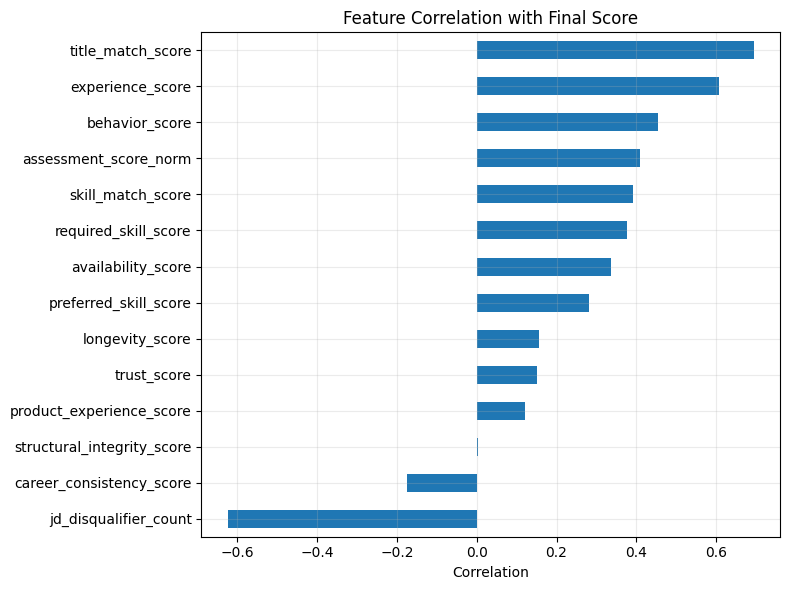

In [ ]:
# S2. Feature Importance Analysis

import matplotlib.pyplot as plt

feature_importance = (
    candidate_df[diagnostic_features]
    .corr(numeric_only=True)["final_score"]
    .drop("final_score")
    .sort_values(ascending=False)
    .rename("Correlation")
    .to_frame()
)

display(feature_importance)

fig, ax = plt.subplots(figsize=(8,6))

feature_importance.sort_values(
    by="Correlation"
).plot.barh(
    ax=ax,
    legend=False
)

ax.set_title("Feature Correlation with Final Score")
ax.set_xlabel("Correlation")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# S3. Feature Distribution Comparison

# Filter features to only those present in both DataFrames to avoid KeyError
available_features = [
    f for f in diagnostic_features
    if f in candidate_df.columns and f in ranked_df.columns
]

distribution_df = pd.DataFrame({

    "Population Mean":
        candidate_df[
            available_features
        ].mean(),

    "Top100 Mean":
        ranked_df.head(100)[
            available_features
        ].mean()

})

distribution_df["Difference"] = (
    distribution_df["Top100 Mean"]    -
    distribution_df["Population Mean"]
)

display(
    distribution_df
    .sort_values(
        "Difference",
        ascending=False
    )
)

,Population Mean,Top100 Mean,Difference
title_match_score,0.163494,0.967000,0.803506
final_score,0.294721,0.635616,0.340896
required_skill_score,0.037113,0.374527,0.337414
behavior_score,0.102904,0.417706,0.314802
availability_score,0.540180,0.770211,0.230032
experience_score,0.740225,0.966900,0.226675
structural_integrity_score,0.678346,0.833929,0.155583
preferred_skill_score,0.006147,0.153333,0.147187
product_experience_score,0.207877,0.281664,0.073787
jd_disqualifier_count,0.687320,0.080000,-0.607320


In [ ]:
# S4. Feature Redundancy & Outlier Analysis

correlation_matrix = (
    candidate_df[
        diagnostic_features
    ]
    .corr(numeric_only=True)
)

high_corr = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

high_corr.columns = [
    "Feature A",
    "Feature B",
    "Correlation"
]

display(
    high_corr[
        high_corr["Correlation"].abs() >= 0.80
    ]
    .sort_values(
        "Correlation",
        ascending=False
    )
)

print("\nHighest Scoring Candidates")

display(
    ranked_df.head(5)
)

print("\nLowest Scoring Candidates")

display(
    ranked_df.tail(5)
)

,Feature A,Feature B,Correlation
0,skill_match_score,required_skill_score,0.997203
60,career_consistency_score,longevity_score,-0.964713



Highest Scoring Candidates


,candidate_id,current_title,years_of_experience,final_score,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,assessment_score,product_experience_score,structural_integrity_score,candidate_quality,jd_disqualifier_count,rank
0,CAND_0018499,Senior Machine Learning Engineer,7.2,0.729795,0.587065,0.222222,0.95,1.00,0.659651,0.839078,83.200000,0.313393,0.867993,"{'skills': 0.5140961857379768, 'title': 0.95, ...",0,1
1,CAND_0008425,Senior NLP Engineer,7.8,0.719658,0.597015,0.222222,0.95,1.00,0.666117,0.755082,77.800000,0.313393,0.874212,"{'skills': 0.5220563847429519, 'title': 0.95, ...",0,2
2,CAND_0081846,Lead AI Engineer,6.7,0.709867,0.686567,0.111111,0.95,1.00,0.488480,0.850895,65.133333,0.208929,0.871161,"{'skills': 0.5714759535655058, 'title': 0.95, ...",0,3
3,CAND_0088025,Staff Machine Learning Engineer,8.6,0.705739,0.487562,0.333333,0.95,0.96,0.545962,0.879096,90.350000,0.321726,0.807496,"{'skills': 0.45671641791044776, 'title': 0.95,...",0,4
4,CAND_0077337,Staff Machine Learning Engineer,7.0,0.693813,0.587065,0.111111,0.95,1.00,0.263047,0.878982,63.200000,0.376190,0.860540,"{'skills': 0.4918739635157546, 'title': 0.95, ...",0,5



Lowest Scoring Candidates


,candidate_id,current_title,years_of_experience,final_score,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,assessment_score,product_experience_score,structural_integrity_score,candidate_quality,jd_disqualifier_count,rank
99995,CAND_0037538,Business Analyst,1.2,0.105914,0.0,0.0,0.0,0.200000,0.046762,0.323708,0.0,0.025000,0.721935,"{'skills': 0.0, 'title': 0.0, 'experience': 0....",2,99996
99996,CAND_0035100,Sales Executive,1.0,0.105677,0.0,0.0,0.0,0.166667,0.097778,0.314320,0.0,0.060714,0.829993,"{'skills': 0.0, 'title': 0.0, 'experience': 0....",3,99997
99997,CAND_0029597,Marketing Manager,1.0,0.104428,0.0,0.0,0.0,0.166667,0.083248,0.339708,0.0,0.060714,0.626410,"{'skills': 0.0, 'title': 0.0, 'experience': 0....",2,99998
99998,CAND_0045514,Marketing Manager,1.0,0.104013,0.0,0.0,0.0,0.166667,0.090920,0.304849,0.0,0.060714,0.824541,"{'skills': 0.0, 'title': 0.0, 'experience': 0....",3,99999
99999,CAND_0005641,Graphic Designer,1.1,0.099985,0.0,0.0,0.0,0.183333,0.065421,0.309991,0.0,0.035714,0.627526,"{'skills': 0.0, 'title': 0.0, 'experience': 0....",2,100000


T. Candidate Deep Dive

In [ ]:
# T1. Candidate Scorecard Helper

scorecard_columns = [

    "rank",
    "candidate_id",
    "current_title",
    "years_of_experience",

    "required_matches",
    "preferred_matches",

    "required_skill_score",
    "preferred_skill_score",

    "title_match_score",

    "experience_score",

    "behavior_score",

    "availability_score",

    "product_experience_score",

    "structural_integrity_score",

    "assessment_score_norm",

    "jd_disqualifier_count",

    "final_score"

]

scorecard_columns = [
    c
    for c in scorecard_columns
    if c in ranked_df.columns
]


def candidate_scorecard(candidate_id):

    display(

        ranked_df.loc[
            ranked_df["candidate_id"] == candidate_id,
            scorecard_columns
        ]

    )

In [ ]:
# T2. Review Top, Borderline & Random Candidates

print("Top 5 Candidates")

for candidate_id in ranked_df.head(5)["candidate_id"]:

    candidate_scorecard(candidate_id)


print("\nBorderline Candidates (Ranks 91-100)")

for candidate_id in ranked_df.iloc[90:100]["candidate_id"]:

    candidate_scorecard(candidate_id)


print("\nRandom Sample")

for candidate_id in ranked_df.sample(
    5,
    random_state=42
)["candidate_id"]:

    candidate_scorecard(candidate_id)

Top 5 Candidates


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
0,1,CAND_0018499,Senior Machine Learning Engineer,7.2,0.587065,0.222222,0.95,1.0,0.659651,0.839078,0.313393,0.867993,0,0.729795


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
1,2,CAND_0008425,Senior NLP Engineer,7.8,0.597015,0.222222,0.95,1.0,0.666117,0.755082,0.313393,0.874212,0,0.719658


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
2,3,CAND_0081846,Lead AI Engineer,6.7,0.686567,0.111111,0.95,1.0,0.48848,0.850895,0.208929,0.871161,0,0.709867


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
3,4,CAND_0088025,Staff Machine Learning Engineer,8.6,0.487562,0.333333,0.95,0.96,0.545962,0.879096,0.321726,0.807496,0,0.705739


...

,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
75721,75722,CAND_0066382,Marketing Manager,5.1,0.0,0.0,0.0,0.85,0.104165,0.461521,0.079464,0.657831,1,0.246186


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
80184,80185,CAND_0060416,Sales Executive,4.8,0.0,0.0,0.0,0.8,0.084947,0.416968,0.170833,0.57037,1,0.237358


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
19864,19865,CAND_0048271,Project Manager,7.8,0.199005,0.0,0.0,1.0,0.102882,0.660721,0.286012,0.701466,1,0.357877


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
76699,76700,CAND_0028870,Project Manager,12.2,0.0,0.0,0.0,0.72,0.08026,0.484836,0.244643,0.673451,1,0.244369


,rank,candidate_id,current_title,years_of_experience,required_skill_score,preferred_skill_score,title_match_score,experience_score,behavior_score,availability_score,product_experience_score,structural_integrity_score,jd_disqualifier_count,final_score
92991,92992,CAND_0070377,Sales Executive,2.5,0.0,0.0,0.0,0.416667,0.056226,0.47479,0.208929,0.72354,1,0.187835


In [ ]:
# T3. Candidate Strengths & Concerns

def candidate_review(row):

    strengths = []
    concerns = []

    if row.get("title_match_score",0) >= 0.90:
        strengths.append("Excellent title alignment")

    if row.get("required_skill_score",0) >= 0.50:
        strengths.append("Strong required skill coverage")

    elif row.get("required_skill_score",0) >= 0.30:
        strengths.append("Moderate required skill coverage")

    if row.get("preferred_skill_score",0) >= 0.20:
        strengths.append("Good preferred skill coverage")

    if row.get("experience_score",0) >= 0.95:
        strengths.append("Excellent experience fit")

    if row.get("product_experience_score",0) >= 0.30:
        strengths.append("Relevant product engineering experience")

    if row.get("availability_score",0) >= 0.75:
        strengths.append("Highly available")

    if row.get("structural_integrity_score",1) >= 0.90:
        strengths.append("Excellent profile integrity")

    if row.get("jd_disqualifier_count",0) > 0:
        concerns.append(
            f"{int(row['jd_disqualifier_count'])} JD compatibility flag(s)"
        )

    if row.get("availability_score",1) < 0.40:
        concerns.append("Low recruiter availability")

    if row.get("structural_integrity_score",1) < 0.70:
        concerns.append("Profile integrity requires review")

    if not strengths:
        strengths.append("Balanced overall candidate profile")

    if not concerns:
        concerns.append("No major concerns identified")

    return pd.Series({

        "Strengths": "; ".join(strengths),
        "Concerns": "; ".join(concerns)

    })

candidate_reviews = ranked_df.head(20).apply(
    candidate_review,
    axis=1
)

display(
    pd.concat(
        [
            ranked_df.head(20)[
                [
                    "rank",
                    "candidate_id",
                    "current_title",
                    "final_score"
                ]
            ],
            candidate_reviews
        ],
        axis=1
    )
)

,rank,candidate_id,current_title,final_score,Strengths,Concerns
0,1,CAND_0018499,Senior Machine Learning Engineer,0.729795,Excellent title alignment; Strong required ski...,No major concerns identified
1,2,CAND_0008425,Senior NLP Engineer,0.719658,Excellent title alignment; Strong required ski...,No major concerns identified
2,3,CAND_0081846,Lead AI Engineer,0.709867,Excellent title alignment; Strong required ski...,No major concerns identified
3,4,CAND_0088025,Staff Machine Learning Engineer,0.705739,Excellent title alignment; Moderate required s...,No major concerns identified
4,5,CAND_0077337,Staff Machine Learning Engineer,0.693813,Excellent title alignment; Strong required ski...,No major concerns identified
5,6,CAND_0064326,Search Engineer,0.691537,Excellent title alignment; Moderate required s...,No major concerns identified
6,7,CAND_0070398,Machine Learning Engineer,0.690481,Excellent title alignment; Strong required ski...,No major concerns identified
7,8,CAND_0030031,AI Engineer,0.684423,Excellent title alignment; Strong required ski...,No major concerns identified
8,9,CAND_0027691,NLP Engineer,0.683909,Excellent title alignment; Moderate required s...,No major concerns identified
9,10,CAND_0071974,Senior AI Engineer,0.683650,Excellent title alignment; Strong required ski...,1 JD compatibility flag(s)


U. Weight Calibration

In [ ]:
# U1. Weight Configuration

CURRENT_WEIGHTS = {
    "skill":0.25,
    "title":0.15,
    "experience":0.18,
    "behavior":0.08,
    "availability":0.12,
    "product":0.12,
    "integrity":0.05,
    "assessment":0.05
}

CURRENT_WEIGHTS

{'skill': 0.25,
 'title': 0.15,
 'experience': 0.18,
 'behavior': 0.08,
 'availability': 0.12,
 'product': 0.12,
 'integrity': 0.05,
 'assessment': 0.05}

In [ ]:
# U2. Weight Sensitivity Analysis

alternative_score = (
      0.25 * candidate_df["skill_match_score"]
    + 0.18 * candidate_df["title_match_score"]
    + 0.16 * candidate_df["experience_score"]
    + 0.06 * candidate_df["behavior_score"]
    + 0.12 * candidate_df["availability_score"]
    + 0.13 * candidate_df["product_experience_score"]
    + 0.05 * candidate_df["structural_integrity_score"]
    + 0.05 * candidate_df["assessment_score_norm"]
)

candidate_df["alternative_score"] = alternative_score.clip(0,1)

comparison = (
    candidate_df[
        [
            "candidate_id",
            "final_score",
            "alternative_score"
        ]
    ]
    .assign(
        final_rank=lambda df:
            df["final_score"]
            .rank(
                ascending=False,
                method="first"
            ),

        alternative_rank=lambda df:
            df["alternative_score"]
            .rank(
                ascending=False,
                method="first"
            )
    )
)

comparison["rank_change"] = (
    comparison["final_rank"]
    -
    comparison["alternative_rank"]
)

display(
    comparison
    .reindex(
        comparison["rank_change"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    .head(20)
)

print()

old_top20 = set(
    candidate_df
    .sort_values(
        "final_score",
        ascending=False
    )
    .head(20)["candidate_id"]
)

new_top20 = set(
    candidate_df
    .sort_values(
        "alternative_score",
        ascending=False
    )
    .head(20)["candidate_id"]
)

print(f"Top 20 Overlap : {len(old_top20 & new_top20)}/20")

old_top100 = set(
    candidate_df
    .sort_values(
        "final_score",
        ascending=False
    )
    .head(100)["candidate_id"]
)

new_top100 = set(
    candidate_df
    .sort_values(
        "alternative_score",
        ascending=False
    )
    .head(100)["candidate_id"]
)

print(f"Top 100 Overlap: {len(old_top100 & new_top100)}/100")

,candidate_id,final_score,alternative_score,final_rank,alternative_rank,rank_change
85192,CAND_0085193,0.261539,0.300010,66348.0,39045.0,27303.0
37350,CAND_0037351,0.264753,0.303946,64255.0,37021.0,27234.0
71936,CAND_0071937,0.261273,0.299490,66501.0,39307.0,27194.0
88410,CAND_0088411,0.265776,0.304934,63649.0,36510.0,27139.0
87545,CAND_0087546,0.253251,0.290808,71565.0,44638.0,26927.0
47732,CAND_0047733,0.256831,0.294053,69366.0,42522.0,26844.0
64780,CAND_0064781,0.266976,0.305863,62869.0,36030.0,26839.0
87691,CAND_0087692,0.250874,0.288129,72997.0,46503.0,26494.0
93170,CAND_0093171,0.268673,0.307166,61726.0,35431.0,26295.0
91090,CAND_0091091,0.256364,0.292241,69672.0,43691.0,25981.0



Top 20 Overlap : 18/20
Top 100 Overlap: 84/100


V. Explainability Engine

In [ ]:
# V1. Generate Candidate Reasoning

def generate_reasoning(row):

    sentences = []

    title = row.get("current_title", "Candidate")
    years = row.get("years_of_experience", 0)

    sentences.append(
        f"{title} with {years:.1f} years of relevant experience."
    )

    strengths = []

    if row.get("title_match_score", 0) >= 0.90:
        strengths.append("excellent title alignment")

    elif row.get("title_match_score", 0) >= 0.80:
        strengths.append("strong title alignment")

    if row.get("required_skill_score", 0) >= 0.50:
        strengths.append("strong required skill coverage")

    elif row.get("required_skill_score", 0) >= 0.30:
        strengths.append("good required skill coverage")

    if row.get("preferred_skill_score", 0) >= 0.20:
        strengths.append("useful preferred skills")

    if row.get("product_experience_score", 0) >= 0.30:
        strengths.append("product engineering experience")

    if row.get("availability_score", 0) >= 0.75:
        strengths.append("high recruiter availability")

    if row.get("structural_integrity_score", 0) >= 0.90:
        strengths.append("excellent profile integrity")

    if strengths:

        sentences.append(
            "Profile demonstrates " +
            ", ".join(strengths) +
            "."
        )

    concerns = []

    if row.get("jd_disqualifier_count", 0) > 0:
        concerns.append(
            f"{int(row['jd_disqualifier_count'])} JD compatibility flag(s)"
        )

    if row.get("availability_score", 1) < 0.40:
        concerns.append("limited recruiter availability")

    if row.get("structural_integrity_score", 1) < 0.70:
        concerns.append("profile consistency requires review")

    if concerns:

        sentences.append(
            "Minor consideration: " +
            ", ".join(concerns) +
            "."
        )

    candidate_num = int(
        str(row["candidate_id"]).split("_")[-1]
    )

    closing_messages = [
        "Overall profile shows strong alignment with the target role.",
        "Profile appears well-positioned for further recruiter evaluation.",
        "Candidate presents a balanced combination of technical and professional strengths.",
        "Overall assessment suggests a competitive fit for the role.",
        "Profile demonstrates a solid foundation for success in this position."
    ]

    sentences.append(
        closing_messages[
            candidate_num % len(closing_messages)
        ]
    )

    return " ".join(sentences)

ranked_df["reasoning"] = ranked_df.apply(
    generate_reasoning,
    axis=1
)

In [ ]:
# V2. Validate Generated Reasoning

# Provide a default for candidates with no specific strengths/concerns identified
ranked_df["reasoning"] = ranked_df["reasoning"].replace("", "Candidate meets baseline requirements for the role.")

display(
    ranked_df[
        [
            "rank",
            "candidate_id",
            "current_title",
            "final_score",
            "reasoning"
        ]
    ]
    .head(20)
)

# Check that no reasonings are null
assert ranked_df["reasoning"].isna().sum() == 0

# Ensure top 100 candidates have substantial reasoning
assert (ranked_df.head(100)["reasoning"].str.len() > 20).all()

print("Reasoning validation passed.")

,rank,candidate_id,current_title,final_score,reasoning
0,1,CAND_0018499,Senior Machine Learning Engineer,0.729795,Senior Machine Learning Engineer with 7.2 year...
1,2,CAND_0008425,Senior NLP Engineer,0.719658,Senior NLP Engineer with 7.8 years of relevant...
2,3,CAND_0081846,Lead AI Engineer,0.709867,Lead AI Engineer with 6.7 years of relevant ex...
3,4,CAND_0088025,Staff Machine Learning Engineer,0.705739,Staff Machine Learning Engineer with 8.6 years...
4,5,CAND_0077337,Staff Machine Learning Engineer,0.693813,Staff Machine Learning Engineer with 7.0 years...
5,6,CAND_0064326,Search Engineer,0.691537,Search Engineer with 7.6 years of relevant exp...
6,7,CAND_0070398,Machine Learning Engineer,0.690481,Machine Learning Engineer with 7.2 years of re...
7,8,CAND_0030031,AI Engineer,0.684423,AI Engineer with 5.7 years of relevant experie...
8,9,CAND_0027691,NLP Engineer,0.683909,NLP Engineer with 6.5 years of relevant experi...
9,10,CAND_0071974,Senior AI Engineer,0.683650,Senior AI Engineer with 7.8 years of relevant ...


Reasoning validation passed.


In [ ]:
# V3. Reasoning Quality Checks

reasoning_stats = pd.DataFrame({

    "Metric":[
        "Unique Reasonings",
        "Average Length",
        "Shortest",
        "Longest"
    ],

    "Value":[

        ranked_df["reasoning"].nunique(),

        ranked_df["reasoning"]
        .str.len()
        .mean(),

        ranked_df["reasoning"]
        .str.len()
        .min(),

        ranked_df["reasoning"]
        .str.len()
        .max()

    ]

})

display(reasoning_stats)

,Metric,Value
0,Unique Reasonings,47406.00000
1,Average Length,198.34898
2,Shortest,110.00000
3,Longest,367.00000


W. Submission Builder

In [ ]:
# W1. Build Submission DataFrame

submission_df = (
    ranked_df
    .head(100)
    .loc[
        :,
        [
            "candidate_id",
            "rank",
            "final_score",
            "reasoning"
        ]
    ]

    .rename(
        columns={
            "final_score":"score"
        }
    )
)

display(submission_df.head())

,candidate_id,rank,score,reasoning
0,CAND_0018499,1,0.729795,Senior Machine Learning Engineer with 7.2 year...
1,CAND_0008425,2,0.719658,Senior NLP Engineer with 7.8 years of relevant...
2,CAND_0081846,3,0.709867,Lead AI Engineer with 6.7 years of relevant ex...
3,CAND_0088025,4,0.705739,Staff Machine Learning Engineer with 8.6 years...
4,CAND_0077337,5,0.693813,Staff Machine Learning Engineer with 7.0 years...


In [ ]:
# W2. Validate Submission

assert len(submission_df) == 100
assert submission_df["candidate_id"].is_unique
assert submission_df["rank"].is_unique
assert submission_df["score"].between(0,1).all()
assert submission_df["score"].is_monotonic_decreasing

print("Submission validation passed.")

Submission validation passed.


In [ ]:
# W3. Export Submission Files

from google.colab import files

CSV_FILE = "team_submission.csv"
EXCEL_FILE = "team_submission.xlsx"

submission_df.to_csv(
    CSV_FILE,
    index=False,
    encoding="utf-8"
)

submission_df.to_excel(
    EXCEL_FILE,
    index=False,
    engine="openpyxl"
)

print("Files created successfully.")

files.download(CSV_FILE)
files.download(EXCEL_FILE)

Files created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

X. Final Report

In [ ]:
# X1. Final Pipeline Summary

pipeline_summary = pd.DataFrame({

    "Metric":[
        "Candidates Evaluated",
        "Candidates Submitted",
        "Highest Score",
        "Lowest Submitted Score",
        "Average Submitted Score",
        "Mean Experience",
        "Mean Product Score",
        "Mean Availability",
        "Mean Integrity"
    ],

    "Value":[
        len(candidate_df),
        len(submission_df),
        submission_df["score"].max(),
        submission_df["score"].min(),
        submission_df["score"].mean(),
        ranked_df.head(100)["years_of_experience"].mean(),
        ranked_df.head(100)["product_experience_score"].mean(),
        ranked_df.head(100)["availability_score"].mean(),
        ranked_df.head(100)["structural_integrity_score"].mean()
    ]
})

display(pipeline_summary)

,Metric,Value
0,Candidates Evaluated,100000.000000
1,Candidates Submitted,100.000000
2,Highest Score,0.729795
3,Lowest Submitted Score,0.602114
4,Average Submitted Score,0.635616
5,Mean Experience,6.533000
6,Mean Product Score,0.281664
7,Mean Availability,0.770211
8,Mean Integrity,0.833929


In [ ]:
# X2. JD Flag Summary

if "jd_disqualifier_count" in ranked_df.columns:

    display(
        ranked_df
        .head(100)
        .groupby("jd_disqualifier_count")
        .size()
        .rename("Candidates")
        .to_frame()
    )

else:
    print("JD Disqualifier information unavailable.")

,Candidates
jd_disqualifier_count,
0,92
1,8


In [ ]:
# X3. Submission Ready Report

print("Notebook 3 Status")
print("-----------------")
print("Ranking Validation        ✓")
print("Feature Diagnostics       ✓")
print("Candidate Review          ✓")
print("Weight Calibration        ✓")
print("Reasoning Generation      ✓")
print("Submission Builder        ✓")
print("Submission Validation     ✓")
print()
print("Status : READY FOR SUBMISSION")

Notebook 3 Status
-----------------
Ranking Validation        ✓
Feature Diagnostics       ✓
Candidate Review          ✓
Weight Calibration        ✓
Reasoning Generation      ✓
Submission Builder        ✓
Submission Validation     ✓

Status : READY FOR SUBMISSION
